Inputs shape: (26, 5)
Outputs shape: (26,)
First 20 rows of raw data:
       floor     sugar      eggs    butter      milk  flavour-score  source
20  0.733334  0.200000  0.666667  0.733334  0.133334      -0.537794  week-1
22  0.667597  0.157201  0.738339  0.678368  0.179636      -0.683325  week-3
21  0.757576  0.101010  0.707071  0.757576  0.151515      -0.710242  week-2
0   0.728186  0.154693  0.732552  0.693997  0.056401      -0.714265    file
4   0.618812  0.331802  0.187288  0.756238  0.328835      -0.829237    file
24  0.501329  0.211390  0.390924  0.970550  0.015922      -0.886618  week-5
17  0.782880  0.536336  0.443284  0.859700  0.010326      -0.935757    file
10  0.536797  0.308781  0.411879  0.388225  0.522528      -1.144785    file
1   0.242384  0.844100  0.577809  0.679021  0.501953      -1.209955    file
6   0.145111  0.896685  0.896322  0.726272  0.236272      -1.233786    file
5   0.784958  0.910682  0.708120  0.959225  0.004911      -1.247049    file
16  0.432166  0.71

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 0.953701, Val Loss: 1.548680
Epoch 50/500, Train Loss: 0.128860, Val Loss: 0.315127
Epoch 100/500, Train Loss: 0.011726, Val Loss: 0.292712
Early stopping at epoch 113, best val_loss=0.238486


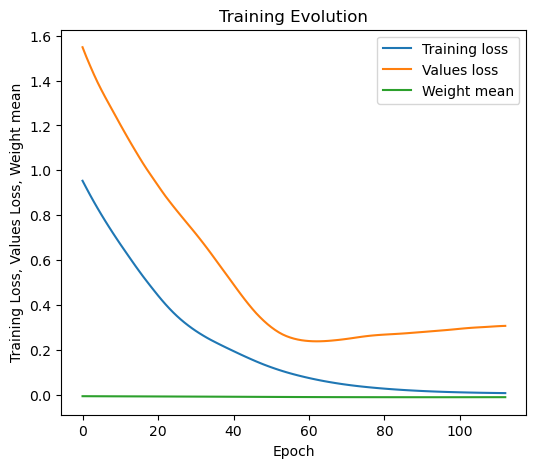

Using 5 dimensions, grid size per axis: 100, downsample: True, stride: 5
Points before downsampling: 10000000000
Points after downsampling: 3200000
Final grid shape: (3200000, 5)
Filtered 333 candidates using filter_strategy='good'
Predictions range (scaled): 0.4967 to 1.0823
Inverse-transforming predictions to raw units
Predictions range (raw): 1.6455 to 1.9412
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.90957446, 1.04692308, 0.80589434, 0.86990788, 0.80419733]), 'score': 0.0002475688976203433, 'dim': 5, 'predicted_y': 1.9278771}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.90957446, 1.04692308, 0.80589434, 0.86990788, 0.80419733]), 'score': 0.00022345372500781797, 'dim': 5, 'predicted_y': 1.9278771}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.90957446, 1.04692308, 0.80589434, 0.86990788, 0.80419733]), 'score': 2.2850448171657216e-05, 'dim': 5, 'predicted_y': 1.9278771}
{'method': 'EI', 'xi': 0.01, 'kappa': N

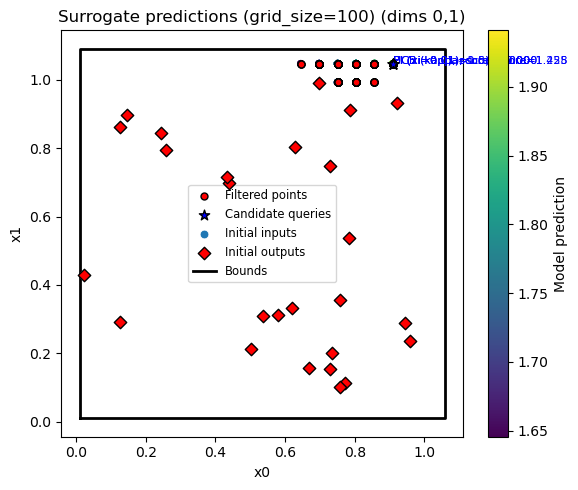

<Figure size 600x500 with 0 Axes>

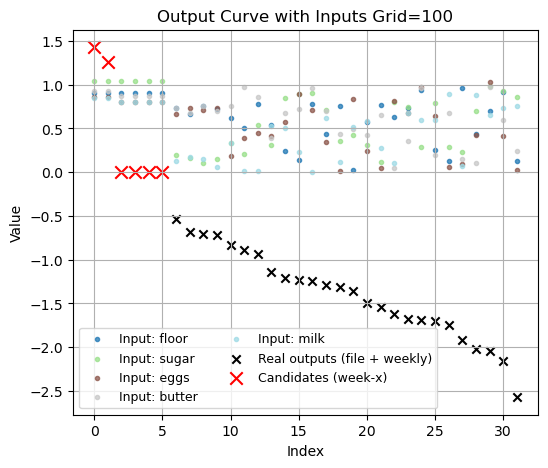

Saved dataframe to: results/run_2025-12-13 22-40-31/df_grid_100_stride5_gp_max_negated_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.90957446, 1.04692308, 0.86274394, 0.92365212, 0.85383466]), 'score': 1.42843770170463, 'dim': 5, 'predicted_y': 1.9411939}
       floor     sugar      eggs    butter      milk  flavour-score  source  flavour-score-scaled
0   0.909574  1.046923  0.862744  0.923652  0.853835       1.428438  week-x             10.000000
1   0.909574  1.046923  0.862744  0.923652  0.853835       1.255353  week-x              8.788293
2   0.909574  1.046923  0.805894  0.869908  0.804197       0.000248  week-x              0.001733
3   0.909574  1.046923  0.805894  0.869908  0.804197       0.000223  week-x              0.001564
4   0.909574  1.046923  0.805894  0.869908  0.804197       0.000023  week-x              0.000160
5   0.909574  1.046923  0.805894  0.869908  0.804197       0.000020  week-x              0.000143
6   0.733334

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))